In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import widgets, Layout, ButtonStyle
from IPython.display import HTML, display, clear_output
import pandas as pd

In [7]:
def popup(text):
    display(HTML("<script>alert('{}');</script>".format(text)))
popup("baba baba")

In [2]:
df = pd.read_csv(r"D:\Projects\Synthetic Data Generation\applications\dataprivacy\dataset\HR_pre_processed_data.csv")

In [12]:
df.head(15)

,Age,Department,Education,EducationField,Gender,JobLevel,MonthlyIncome,PercentSalaryHike,TotalWorkingYears,YearsAtCompany
0,41,2,2,1,0,2,5993,11,8,6
1,49,1,1,1,1,2,5130,23,10,10
2,37,1,2,4,1,1,2090,15,7,0
3,33,1,4,1,0,1,2909,11,8,8
4,27,1,1,3,1,1,3468,12,6,2
5,32,1,2,1,1,1,3068,13,8,7
6,59,1,3,3,0,1,2670,20,12,1
7,30,1,1,1,1,1,2693,22,1,1
8,38,1,3,1,1,3,9526,21,10,9
9,36,1,3,3,1,2,5237,13,17,7


In [18]:
lst = pd.cut(df["Age"], [30, 45, 50]).values

In [20]:
df[df["Age"]<30]["Age"]

4       27
11      29
14      28
15      29
17      22
        ..
1442    29
1459    29
1460    29
1464    26
1467    27
Name: Age, Length: 326, dtype: int64

In [21]:
lst[4]

nan

In [22]:
lst

[(30.0, 45.0], (45.0, 50.0], (30.0, 45.0], (30.0, 45.0], NaN, ..., (30.0, 45.0], (30.0, 45.0], NaN, (45.0, 50.0], (30.0, 45.0]]
Length: 1470
Categories (2, interval[int64, right]): [(30, 45] < (45, 50]]

In [24]:
[i for i in df.columns.values]

['Age',
 'Department',
 'Education',
 'EducationField',
 'Gender',
 'JobLevel',
 'MonthlyIncome',
 'PercentSalaryHike',
 'TotalWorkingYears',
 'YearsAtCompany']

In [358]:
class psuedo:
    def __init__(self):
        self.df = pd.read_csv(
            r"D:\Projects\Synthetic Data Generation\applications\dataprivacy\dataset\HR_pre_processed_data.csv")
        self.discrete = ["Department", "Education", "EducationField", "Gender", "JobLevel"]
        self.numerical = [i for i in self.df.columns.values if i not in self.discrete]
        self.numerical_feature_base = {i:{"auto":None, "custom":[], "noise":0} for i in self.numerical}
        self.discrete_feature_base = {i:{"auto":None, "custom":{}} for i in self.discrete}
    def numerical_psuedo_mode(self):
        if len(self.numerical)==0:
            h = widgets.HTML("<h4 style='text-align:center; width:100%; color:red'> There is no numerical data available... </h4>")
            return h
        def create_binners(value, list_of_values_refil=None):
            self.bin_scalar_list = []
            for i in range(value):
                temp = widgets.IntText(value=2, description=f'Edge {i+1} value:',disabled=False, style={"description_width":"100px"})
                if list_of_values_refil is not None:
                    temp = widgets.IntText(value=list_of_values_refil[i], description=f'Edge {i+1} value:',disabled=False, style={"description_width":"100px"})
                self.bin_scalar_list.append(temp)
            self.h4.children = self.bin_scalar_list
        def on_change_feature(change):
            if self.numerical_feature_base == None:
                self.numerical_feature_base = {i:{"auto":None, "custom":[], "noise":0} for i in self.numerical}
            if change["type"] == "change" and change["name"] == "value":
                if self.binning_dropdown.value == "Auto":
                    self.numerical_feature_base[change["old"]]["auto"] = self.binning_value_input.value
                    self.numerical_feature_base[change["old"]]["custom"] = []
                else:
                    lst = []
                    for i in self.bin_scalar_list:
                        lst.append(i.value)
                    self.numerical_feature_base[change["old"]]["custom"] = lst
                    self.numerical_feature_base[change["old"]]["auto"] = None
                self.numerical_feature_base[change["old"]]["noise"] = self.noise_slider.value
                self.noise_slider.value = self.numerical_feature_base[change["new"]]["noise"]
                if len(self.numerical_feature_base[change["new"]]["custom"])!=0:
                    self.binning_dropdown.value = "Custom"
                    self.binning_value_input.value = len(self.numerical_feature_base[change["new"]]["custom"])
                    create_binners(len(self.numerical_feature_base[change["new"]]["custom"]), self.numerical_feature_base[change["new"]]["custom"])
                else:
                    self.binning_dropdown.value = "Auto"
                    self.binning_value_input.value = 2 if self.numerical_feature_base[change["new"]]["auto"]==None else self.numerical_feature_base[change["new"]]["auto"]
        def on_change_binning(change):
            if change["type"] == "change" and change["name"] == "value":
                if self.binning_dropdown.value == "Custom":
                    create_binners(self.binning_value_input.value)
                else:
                    self.bin_scalar_list = []
                    self.h4.children = []
        def on_reset_event(_):
            self.numerical_feature_base = {i:{"auto":None, "custom":[], "noise":0} for i in self.numerical}
            self.binning_dropdown.value = "Auto"
            self.binning_value_input.value = 2
            self.feature_dropdown.value = self.numerical[0]
            self.noise_slider.value = 0
            
        self.feature_dropdown = widgets.Select(
                                                options=list(self.numerical_feature_base.keys()),
                                                description="Select Feature:",
                                                style={"description_width": "150px"},
                                                layout={"width": "45%"},
                                                )
        self.feature_dropdown.observe(on_change_feature)
        
        self.noise_slider = widgets.IntSlider(min=0, max=10, step=1, description="Noise Parameter:",
                                              value=self.numerical_feature_base[self.feature_dropdown.value]["noise"],
                                              style = {"description_width":"150px"}, layout={"width":"70%"})
        
        self.binning_dropdown = widgets.Dropdown(options=["Auto", "Custom"], description="Select Binning Technique:",
                                                style={"description_width": "310px"},layout={"width": "55%"},)
        self.binning_dropdown.observe(on_change_binning)
        
        self.binning_value_input = widgets.IntText(value=2,description='Bins :',
                                                   style={"description_width": "45px"},layout={"width": "30%"},)
        self.binning_value_input.observe(on_change_binning)
        
        reset_button = widgets.Button(description="Reset",style=ButtonStyle(button_color="orange"), layout={"position": "absolute", "left": "46%"})
        reset_button.on_click(on_reset_event)
        
        box_layout = widgets.Layout(display="flex", align_items="center", width="100%")
        h1 = widgets.VBox([self.feature_dropdown, widgets.HTML("<BR>")], layout= box_layout)
        h2 = widgets.VBox([self.noise_slider,  widgets.HTML("<BR>")], layout= box_layout)
        h3 = widgets.HBox([self.binning_dropdown, self.binning_value_input,  widgets.HTML("<BR><BR>")], layout= box_layout)
        
        self.h4 = widgets.VBox(layout= box_layout)
        h5 = widgets.HBox([widgets.HTML("<BR><BR>"), reset_button], layout=box_layout)
        h = widgets.VBox([h1, h2, h3, self.h4, h5])
        return h
    def psuedoMode(self):
        numerical_accordion_child = self.numerical_psuedo_mode()
#         categorical_accordion_child = self.categorical_psuedo_mode()
        accordion_settings = widgets.Accordion(children=[numerical_accordion_child], selected_index=0)
        accordion_settings.set_title(0, "Numerical Level (Pseudonymization)")
#         accordion_settings.set_title(1, "Categorical Level (Pseudonymization)")
        display(accordion_settings)

In [359]:
p = psuedo()
p.psuedoMode()

Accordion(children=(VBox(children=(VBox(children=(Select(description='Select Feature:', layout=Layout(width='4…

In [360]:
df = pd.read_csv(r"D:\Projects\Synthetic Data Generation\applications\dataprivacy\dataset\HR_pre_processed_data.csv")
discrete = ["Department", "Education", "EducationField", "Gender", "JobLevel"]
numerical = [i for i in df.columns.values if i not in discrete]
numerical_feature_base = {i:{"auto":None, "custom":[], "noise":0} for i in numerical}
discrete_feature_base = {i:{"auto":None, "custom":{}} for i in discrete}


In [ ]:
def observe_binning(_):
    return [widgets.HTML(f'<b>{i+1}</b>') for i in range(binning.value)]

In [11]:
class numerical_discretization_noise:
    def __init__(self):
        self.df = pd.read_csv(
            r"D:\Projects\Synthetic Data Generation\applications\dataprivacy\dataset\HR_pre_processed_data.csv")
        self.discrete = ["Department", "Education", "EducationField", "Gender", "JobLevel"]
        self.numerical = [i for i in self.df.columns.values if i not in self.discrete]
        self.numerical_feature_base = {i:{"bins":[], "freq" : [], "noise":0} for i in self.numerical}
        self.discrete_feature_base = {i:{"auto":None, "custom":{}} for i in self.discrete}
    def update_binners(self, bin_number):
        def update(change):
            if change["name"] == "value" and change["type"] == "change":
                pass
#                 print("\n",bin_number, "\n", change, "\n" , self.numerical_feature_base)
        return update
    
    def create_binners(self, feature, set_binners = False):
        if not set_binners:
            slice_df_feature = pd.cut(self.df[feature], bins=self.binning_selection.value)
            slice_df_feature.dropna(inplace=True)
            list_intervals = list(slice_df_feature.unique())
            list_intervals.sort()
            self.numerical_feature_base[feature] = {"bins":[], "freq" : [], "noise":0}
            for l in list_intervals:
                self.numerical_feature_base[feature]["bins"].append([l.left, l.right])
                self.numerical_feature_base[feature]["freq"].append(len(slice_df_feature[slice_df_feature == l]))
        minimum_value = self.numerical_feature_base[feature]["bins"][0][0]
        maximum_value = self.numerical_feature_base[feature]["bins"][-1][1]
        self.fs_childs = [widgets.HTML(f'<b>Start</b>')]
        self.fe_childs = [widgets.HTML(f'<b>End</b>')]
        self.fv_childs = [widgets.HTML(f'<b>Frequency</b>')]
        bin_labels_list = []
        for i in range(self.binning_selection.value):
            start_value = self.numerical_feature_base[feature]["bins"][i][0]
            end_value = self.numerical_feature_base[feature]["bins"][i][1]
            layout = {"width":"90%"}
            start_temp_textbox = widgets.BoundedFloatText(value=start_value,  min=minimum_value, max=maximum_value, disabled=True, layout=layout)
            end_temp_textbox = widgets.BoundedFloatText(value=end_value, min=minimum_value, max=maximum_value, layout=layout)
            if i+1 == self.binning_selection.value:
                end_temp_textbox.disabled = True
            else:
                end_temp_textbox.observe(self.update_binners(i))
            freq_value_label = widgets.Label(value='{}'.format(self.numerical_feature_base[feature]["freq"][i]))
            bin_labels_list.append(widgets.HTML(f'<b>Bin {i+1}:</b>'))
            self.fs_childs.append(start_temp_textbox)
            self.fe_childs.append(end_temp_textbox)
            self.fv_childs.append(freq_value_label)
        self.bin_labels.children = bin_labels_list
        self.frequency_based_values.children = self.fv_childs
        self.frequency_start_values.children = self.fs_childs
        self.frequency_end_values.children = self.fe_childs
            
    def numerical_discretization_noise_app(self):
        def on_change_binning(change):
            if self.numerical_feature_base == None:
                self.numerical_feature_base = {i:{"bins":[], "freq" : [], "noise":0} for i in self.numerical}
            if change["type"] == "change" and change["name"] == "value":
                if self.binning_selection.value != "--None--":
                    self.create_binners(self.feature_selection.value)
        def on_change_feature(change):
            if self.numerical_feature_base == None:
                self.numerical_feature_base = {i:{"bins":[], "freq" : [], "noise":0} for i in self.numerical}
            if change["type"] == "change" and change["name"] == "value":
                if len(self.numerical_feature_base[change["new"]]["bins"]) > 0:
                    self.radio_buttons.value = "Binning"
                    self.binning_selection.value = len(self.numerical_feature_base[change["new"]]["bins"])
                    self.create_binners(change["new"], set_binners=True)
                else:
                    self.radio_buttons.value = "Noise"
                    self.noise_selection.value = self.numerical_feature_base[change["new"]]["noise"]
        def on_change_radio(change):
            if change["type"] == "change" and change["name"] == "value":
                if change["new"]=="Noise":
                    reset()
                    self.numerical_feature_base[self.feature_selection.value]["bins"] = []
                    self.numerical_feature_base[self.feature_selection.value]["freq"] = []
                    self.right_side_box.children = [self.noise_box]
                else:
                    reset()
                    self.numerical_feature_base[self.feature_selection.value]["noise"] = 0
                    self.right_side_box.children = [self.binning_box]
        def on_change_noise(change):
            if change["type"] == "change" and change["name"] == "value":
                self.numerical_feature_base[self.feature_selection.value]["noise"] = change["new"]
            
        def reset(hard_reset=False):
            self.binning_selection.value = "--None--"
            self.noise_selection.value = self.numerical_feature_base[self.feature_selection.value]["noise"]
            self.frequency_based_values.children = []
            self.frequency_start_values.children = []
            self.frequency_end_values.children = []
            self.bin_labels.children = []
            def reset_event(_):
                if hard_reset:
                    self.numerical_feature_base = {i:{"bins":[], "freq" : [], "noise":0} for i in self.numerical}
            return reset_event
            
        self.feature_selection_tag = widgets.HTML("<b>Select Feature:</b>")
        self.feature_selection = widgets.Select(options=list(self.numerical_feature_base.keys()),
                                          description="", rows=10)
        self.feature_selection.observe(on_change_feature)
        feature_box = widgets.VBox([self.feature_selection_tag, self.feature_selection])

        verical_line_html = '''<style>
                .vertical {
                    border-left: 2px solid black;
                    height: 200px;
                    position:absolute;
                    left: 50%;
                }
            </style><div class = "vertical"></div>'''
        vertical_line = widgets.HTML(verical_line_html)
        radio_button_tag = widgets.HTML("<b>Select Method:</b>")
        self.radio_buttons = widgets.RadioButtons(options = ["Noise", "Binning"], layout={"margin":"60px 0px 0px 10px", "width":"230px"})
        self.radio_buttons.observe(on_change_radio)
        radio_button_box = widgets.VBox([radio_button_tag, self.radio_buttons])

        noise_tag = widgets.HTML("<b>Add Noise (in %):</b>")
        self.noise_selection = widgets.Dropdown(options = list(range(0,101,10)))
        self.noise_selection.observe(on_change_noise)
        self.noise_box = widgets.VBox([noise_tag, self.noise_selection])
        
        binning_tag = widgets.HTML("<b>Select Bin:</b>")
        binning_options = ["--None--"] + list(range(1,11))
        self.binning_selection = widgets.Dropdown(options = binning_options)
        self.binning_selection.observe(on_change_binning)
        self.frequency_based_values = widgets.VBox([])
        self.frequency_start_values = widgets.VBox([])
        self.frequency_end_values = widgets.VBox([])
        self.bin_labels = widgets.VBox([])
        self.binning_custom_box = widgets.HBox([self.frequency_start_values, self.frequency_end_values, self.frequency_based_values])
        self.binning_box = widgets.VBox([binning_tag, self.binning_selection, self.binning_custom_box])
        
        self.right_side_box = widgets.VBox([self.noise_box])
        h = widgets.HBox([feature_box, vertical_line, radio_button_box, self.right_side_box])
        display(h)
nr = numerical_discretization_noise()
nr.numerical_discretization_noise_app()

In [38]:
def split(a, n):
        k, m = divmod(len(a), n)
        return (a[i*k+min(i, m):(i+1)*k+min(i+1, m)] for i in range(n))
class categorical_supression:
    def __init__(self):
        self.df = pd.read_csv(
            r"D:\Projects\Synthetic Data Generation\applications\dataprivacy\dataset\HR_pre_processed_data.csv")
        self.discrete = ["Department", "Education", "EducationField", "Gender", "JobLevel"]        
        self.discrete_feature_base = {i:{"group_name":[], "bins":{}} for i in self.discrete}
        
    def on_textbox_update(self, i):
        def on_update(change):
            if change["type"] == "change" and change["name"] == "value":
                self.discrete_feature_base[self.categorical_feature_dropdown.value]["group_name"][i] = change["new"]
                dropdown_old_value = self.group_drop_down.value
                self.group_drop_down.options = ["--None--"] + self.discrete_feature_base[self.categorical_feature_dropdown.value]["group_name"]
                if dropdown_old_value == change["old"]:
                    self.group_drop_down.value = change["new"]
        return on_update
    def update_event(self,change):
            if change["new"] == "--None--":
                return None
            index = self.discrete_feature_base[self.categorical_feature_dropdown.value]["group_name"].index(self.group_drop_down.value)
            keys = list(self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"])
            selected_key = keys[index]
            for i in range(self.categorical_binning.value):
                if len(self.select_box_childs[i].value)>0:            
                    selected_values = self.select_box_childs[i].value
                    new_selected_key = keys[i]
                    x = self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"][new_selected_key]
                    self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"][new_selected_key] = [item for item in x if item not in selected_values]
                    self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"][selected_key] += selected_values
                    self.select_box_childs[i].value = []
            for i in range(self.categorical_binning.value):
                self.select_box_childs[i].options = self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"][f'g{i}']
            self.group_drop_down.value = "--None--"
            print(self.discrete_feature_base)
    def create_binners(self, set_binners = False):
        if not set_binners:
            list_values = list(self.df[self.categorical_feature_dropdown.value].value_counts().index)[::-1]
            temp_list = list(split(list_values, self.categorical_binning.value))
            self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"] = {f'g{i}': l for i,l in enumerate(temp_list)}
            self.discrete_feature_base[self.categorical_feature_dropdown.value]["group_name"] = [f'g{i+1}'for i in range(len(temp_list))]
        self.select_box_childs, self.text_box_childs = [], []
        for i in range(self.categorical_binning.value):
            options = self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"][f'g{i}']
            text_value = self.discrete_feature_base[self.categorical_feature_dropdown.value]["group_name"][i]
            temp_select_widget = widgets.SelectMultiple(options = options, layout={"width":"150px"})
            temp_text_widget = widgets.Text(value= text_value, layout={"width":"150px"})
            temp_text_widget.observe(self.on_textbox_update(i))
            self.select_box_childs.append(temp_select_widget)
            self.text_box_childs.append(temp_text_widget)
        group_dropdown_options = ["--None--"] + self.discrete_feature_base[self.categorical_feature_dropdown.value]["group_name"]
        self.group_drop_down = widgets.Dropdown(options = group_dropdown_options)
        self.group_drop_down.observe(self.update_event, names="value")
        self.select_box.children = self.select_box_childs
        self.text_box.children= self.text_box_childs
        self.group_drop_box.children = [self.group_drop_down]
        
            
    def categorical_suppresser_app(self):
        if len(self.discrete)==0:
            h = widgets.HTML("<h4 style='text-align:center; width:100%; color:red'> There is no categorical data available... </h4>")
            return h
        def on_change_feature(change):
            if self.discrete_feature_base == None:
                self.discrete_feature_base = {i:{"group_name":[], "bins":{}} for i in self.discrete}
            if change["type"] == "change" and change["name"] == "value":
                self.binning_options = ["--None--"] + list(range(1, len(self.df[self.categorical_feature_dropdown.value].unique())+1))
                self.categorical_binning.options = self.binning_options
                self.categorical_binning.value = self.binning_options[0]
                bin_value_current_feature = len(self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"])
                reset()
                if bin_value_current_feature > 0:
                    self.categorical_binning.value = bin_value_current_feature
                    self.create_binners(set_binners=True)
        def on_change_binning(change):
            if change["type"] == "change" and change["name"] == "value":
                if change["new"] != "--None--":
                    self.create_binners()
                else:
                    reset()
        def reset(hard_reset=False):
            self.select_box.children = []
            self.text_box.children = []
            self.group_drop_box.children = []
            def reset_event(_):
                if hard_reset:
                    self.discrete_feature_base = {i:{"group_name":[], "bins":{}} for i in self.discrete}
            return reset_event
        self.categorical_feature_dropdown = widgets.Dropdown(
                                                options=list(self.discrete_feature_base.keys()),
                                                description="Select Feature:",
                                                style={"description_width": "150px"},
                                                layout={"width": "45%"},
                                                )
        self.categorical_feature_dropdown.observe(on_change_feature)
        
        self.binning_options =  ["--None--"] + list(range(1, len(self.df[self.categorical_feature_dropdown.value].unique())+1))
        self.categorical_binning = widgets.Dropdown(options = self.binning_options,description='Bins :',
                                                   style={"description_width": "150px"},
                                                layout={"width": "45%"},)
        self.categorical_binning.observe(on_change_binning)
        
        box_layout = widgets.Layout(display="flex", align_items="center", width="100%")
        feature_box = widgets.VBox([self.categorical_feature_dropdown, widgets.HTML("<BR>")], layout= box_layout)
        
        bin_box = widgets.VBox([self.categorical_binning,  widgets.HTML("<BR>")], layout= box_layout)
        
        self.select_box = widgets.HBox()
        self.text_box = widgets.HBox()
        self.group_drop_box = widgets.HBox()
        binn_supressor_box = widgets.VBox([self.select_box, self.text_box, self.group_drop_box], layout=box_layout)
        
        c_h = widgets.VBox([feature_box, bin_box, binn_supressor_box])
        return c_h
        accordion_settings = widgets.Accordion(children=[c_h], selected_index=0)
        accordion_settings.set_title(0, "Categorical Level (Pseudonymization)")
        display(accordion_settings)
nr = categorical_supression()
nr.categorical_suppresser_app()

In [684]:
temp = {'Department': {'group_name': ['g1', 'g2'], 'bins': {'g0': [0, 2], 'g1': [1]}}, 
        'Education': {'group_name': ['g1', 'g2', 'g3'], 'bins': {'g0': [5, 1], 'g1': [2, 4], 'g2': [3]}}, 
        'EducationField': {'group_name': ['g1', 'g2'], 'bins': {'g0': [0, 4, 5], 'g1': [2, 3, 1]}}, 
        'Gender': {'group_name': [], 'bins': {}}, 'JobLevel': {'group_name': [], 'bins': {}}}
s_df = df.copy()
for i in temp:
    s_df[i] = s_df[i].astype(str)
    for j in range(len(temp[i]["group_name"])):
        bins_keys = list(temp[i]["bins"].keys())
        bins = map(str, temp[i]["bins"][bins_keys[j]])
        s_df[i] = np.where(s_df[i].isin(bins), temp[i]["group_name"][j], s_df[i])
#         print(j, bin_keys[j], temp[i]["group_name"][j])
s_df.head()

,Age,Department,Education,EducationField,Gender,JobLevel,MonthlyIncome,PercentSalaryHike,TotalWorkingYears,YearsAtCompany
0,41,g1,g2,g2,0,2,5993,11,8,6
1,49,g2,g1,g2,1,2,5130,23,10,10
2,37,g2,g2,g1,1,1,2090,15,7,0
3,33,g2,g2,g2,0,1,2909,11,8,8
4,27,g2,g1,g2,1,1,3468,12,6,2


In [96]:
class date_zip_hashing:
    def __init__(self):
        self.df = pd.read_csv(
            r"D:\Projects\Synthetic Data Generation\applications\dataprivacy\dataset\HR_pre_processed_data.csv")
        self.discrete = ["Department", "Education", "EducationField", "Gender", "JobLevel"]
        self.date = ["date"]
        self.zip = ["zip"]
        self.dz_feature_base = {i:{"noise": 0, "aggregation":None} for i in self.date + self.zip}
    def create_widgets(self):
        box_layout = widgets.Layout(display="flex", align_items="center", width="100%")
        self.feature_selection = widgets.Dropdown(options=self.date + self.zip,
                                          description="Select Features:", style = {"description_width":"150px"},layout={"width": "45%"})
        self.feature_selection_box = widgets.VBox([self.feature_selection, widgets.HTML("<BR>")],  layout=box_layout)
        self.radio_buttons = widgets.RadioButtons(id = "Method", options = ["Noise", "Aggregation"], description="Select Method:", style = {"description_width":"150px"},layout={"width": "45%"})
        self.radio_button_box = widgets.VBox([self.radio_buttons], layout = box_layout)
        
        self.noise_selection = widgets.Dropdown(id = "noise", options = list(range(-5,5)), value=0, description = "Add Noise (in days):", style = {"description_width":"150px"},layout={"width": "45%"})    
        self.noise_box = widgets.VBox([self.noise_selection], layout = box_layout)
        
        discrete_options = ["--None--", "Weekday", "Weekend", "Week of the year", "Month", "Quarter", "year"]
        self.date_aggregate_selection = widgets.Dropdown(id = "date_agg", options = discrete_options, value=discrete_options[0], description = "Select Date Aggregation Value:", style = {"description_width":"150px"},layout={"width": "45%"})
        self.date_aggregation_box = widgets.VBox([self.date_aggregate_selection], layout =box_layout)
        
        discrete_options = ["--None--", "County", "State"]
        self.zip_aggregate_selection = widgets.Dropdown(options = discrete_options, value=discrete_options[0], description = "Select ZIP-Code Aggregation Value:", style = {"description_width":"250px"},layout={"width": "55%", "margin":"0px 0px 0px -97px"})
        self.zip_aggregation_box = widgets.VBox([self.zip_aggregate_selection], layout=box_layout)
        

    def app(self):
        self.create_widgets()
        def on_change_feature(change):
            if self.dz_feature_base == None:
                self.dz_feature_base = {i:{"noise": 0, "aggregation":None, "hashing":None} for i in zip(self.discrete, self.date, self.zip)}
            if change["type"] == "change" and change["name"] == "value":
                if self.feature_selection.value in self.date:
                    if self.dz_feature_base[self.feature_selection.value]["aggregation"] == None:
                        self.radio_buttons.value = "Noise"
                        self.noise_aggregation_box.children = [self.radio_button_box, self.noise_box]
                    else: 
                        self.radio_buttons.value = "Aggregation"
                        self.noise_aggregation_box.children = [self.radio_button_box, self.date_aggregate_selection]
                else:
                    if self.dz_feature_base[self.feature_selection.value]["aggregation"] != None:
                        print("in if")
                        self.zip_aggregate_selection.value = self.dz_feature_base[self.feature_selection.value]["aggregation"]
                    else: 
                        self.zip_aggregate_selection.value = "--None--"
                    self.noise_aggregation_box.children = [self.zip_aggregation_box]
        def on_change_radio(change):
            if change["type"] == "change" and change["name"] == "value":
                pass
                if change["new"]=="Noise":
                    self.dz_feature_base[self.feature_selection.value]["aggregation"]  = None
                    self.noise_aggregation_box.children = [self.radio_button_box, self.noise_box]
                else:
                    self.dz_feature_base[self.feature_selection.value]["noise"]  = 0
                    self.noise_aggregation_box.children = [self.radio_button_box, self.date_aggregation_box]
        def on_change_values(change):
            if change["type"] == "change" and change["name"] == "value":
                if self.feature_selection.value in self.date and self.radio_buttons.value == "Noise":
                    self.dz_feature_base[self.feature_selection.value]["noise"] = change["new"]
                elif self.feature_selection.value in self.date and self.radio_buttons.value == "Aggregation":
                    self.dz_feature_base[self.feature_selection.value]["aggregation"] = change["new"]
                elif self.feature_selection.value in self.zip:
                    self.dz_feature_base[self.feature_selection.value]["aggregation"] = change["new"]
            
        self.feature_selection.observe(on_change_feature)
        self.radio_buttons.observe(on_change_radio)
        self.noise_selection.observe(on_change_values)
        self.date_aggregate_selection.observe(on_change_values)
        self.zip_aggregate_selection.observe(on_change_values)
        
        self.noise_aggregation_box = widgets.VBox([self.radio_button_box, self.noise_box], layout=widgets.Layout(display="flex", align_items="center", width="100%"))
        h = widgets.VBox([self.feature_selection_box, self.noise_aggregation_box], )
        display(h)
dzh = date_zip_hashing()
dzh.app()

In [95]:
class hashing:
    def __init__(self):
        self.df = pd.read_csv(
            r"D:\Projects\Synthetic Data Generation\applications\dataprivacy\dataset\HR_pre_processed_data.csv")
        self.discrete = ["Department", "Education", "EducationField", "Gender", "JobLevel"]
        self.hashing_feature_base = {i:{"hashing": False} for i in self.discrete}
    def create_widgets(self):
        box_layout = widgets.Layout(display="flex", align_items="center", width="100%")
        feature_selection_tag = widgets.HTML("<b>Select Feature:</b>")
        self.feature_selection = widgets.SelectMultiple(options=self.discrete,
                                          description="", rows=10)
        feature_box = widgets.VBox([feature_selection_tag, self.feature_selection])
        verical_line_html = '''<style>
                .vertical {
                    border-left: 2px solid black;
                    height: 165px;
                    position:absolute;
                }
            </style><div class = "vertical"></div>'''
        vertical_line = widgets.HTML(verical_line_html)
        self.feature_selection_box = widgets.HBox([self.feature_selection, vertical_line], layout={"width":"45%"})
        self.radio_buttons = widgets.RadioButtons(options = ["Yes", "No"], value="No", description="Do you want to hash the selected features?", style = {"description_width":"260px"},layout={"width": "90%"})
        self.radio_button_box = widgets.VBox([self.radio_buttons], layout = box_layout)
        
        
        

    def app(self):
        self.create_widgets()
        def on_change_feature(change):
            if self.hashing_feature_base == None:
                self.hashing_feature_base =  {i:{"hashing": False} for i in self.discrete}
            if change["type"] == "change" and change["name"] == "value":
                self.radio_buttons.value = "No"
                
        def on_change_radio(change):
            if change["type"] == "change" and change["name"] == "value":
                for i in self.feature_selection.value:
                        self.hashing_feature_base[i]["hashing"] = True
                if change["new"]=="Yes":
                    for i in self.feature_selection.value:
                        self.hashing_feature_base[i]["hashing"] = True
                else:
                    for i in self.feature_selection.value:
                        self.hashing_feature_base[i]["hashing"] = False
                
            
        self.feature_selection.observe(on_change_feature)
        self.radio_buttons.observe(on_change_radio)
        
        self.noise_aggregation_box = widgets.VBox([self.radio_button_box], layout=widgets.Layout(display="flex", align_items="center", width="100%"))
        h = widgets.HBox([self.feature_selection_box, self.radio_button_box], )
        display(h)
hashy = hashing()
hashy.app()

{'Department': {'hashing': True}, 'Education': {'hashing': True}, 'EducationField': {'hashing': True}, 'Gender': {'hashing': False}, 'JobLevel': {'hashing': False}}
{'Department': {'hashing': True}, 'Education': {'hashing': True}, 'EducationField': {'hashing': False}, 'Gender': {'hashing': False}, 'JobLevel': {'hashing': False}}


In [158]:
class categoricalSupression:
    def __init__(self, df, discrete):
        self.df = df
        self.discrete = discrete       
        self.discrete_feature_base = {i:{"group_name":[], "bins":{}} for i in self.discrete}
        self.categorical_feature_name_hashing = {i:i for i in discrete}
        
    def on_textbox_update(self, i):
        def on_update(change):
            if change["type"] == "change" and change["name"] == "value":
                self.discrete_feature_base[self.categorical_feature_dropdown.value]["group_name"][i] = change["new"]
                dropdown_old_value = self.group_drop_down.value
                self.group_drop_down.options = ["--None--"] + self.discrete_feature_base[self.categorical_feature_dropdown.value]["group_name"]
                if dropdown_old_value == change["old"]:
                    self.group_drop_down.value = change["new"]
        return on_update
    def update_event(self,change):
            if change["new"] == "--None--":
                return None
            index = self.discrete_feature_base[self.categorical_feature_dropdown.value]["group_name"].index(self.group_drop_down.value)
            keys = list(self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"])
            selected_key = keys[index]
            for i in range(self.categorical_binning.value):
                if len(self.select_box_childs[i].value)>0:            
                    selected_values = self.select_box_childs[i].value
                    new_selected_key = keys[i]
                    x = self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"][new_selected_key]
                    self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"][new_selected_key] = [item for item in x if item not in selected_values]
                    self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"][selected_key] += selected_values
                    self.select_box_childs[i].value = []
            for i in range(self.categorical_binning.value):
                self.select_box_childs[i].options = self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"][f'g{i}']
            self.group_drop_down.value = "--None--"
    def create_binners(self, set_binners = False):
        if not set_binners:
            list_values = list(self.df[self.categorical_feature_dropdown.value].value_counts().index)[::-1]
            temp_list = list(split(list_values, self.categorical_binning.value))
            self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"] = {f'g{i}': l for i,l in enumerate(temp_list)}
            self.discrete_feature_base[self.categorical_feature_dropdown.value]["group_name"] = [f'g{i+1}'for i in range(len(temp_list))]
        self.select_box_childs, self.text_box_childs = [], []
        for i in range(self.categorical_binning.value):
            options = self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"][f'g{i}']
            text_value = self.discrete_feature_base[self.categorical_feature_dropdown.value]["group_name"][i]
            temp_select_widget = widgets.SelectMultiple(options = options, layout={"width":"100px"})
            temp_text_widget = widgets.Text(value= text_value, layout={"width":"100px"}, placeholder="Group Name")
            temp_text_widget.observe(self.on_textbox_update(i))
            self.select_box_childs.append(temp_select_widget)
            self.text_box_childs.append(temp_text_widget)
        group_dropdown_options = ["--None--"] + self.discrete_feature_base[self.categorical_feature_dropdown.value]["group_name"]
        width_value = 300 if self.categorical_binning.value > 2 else 209
        self.group_drop_down = widgets.Dropdown(options = group_dropdown_options, description = "Change Grouping:", style = {"description_width":"110px"}, layout={"width":"{}px".format(width_value)})
        self.group_drop_down.observe(self.update_event, names="value")
        self.select_box.children = self.select_box_childs
        self.text_box.children= self.text_box_childs
        if self.categorical_binning.value > 1:
            self.group_drop_box.children = [self.group_drop_down]
        else:
            self.group_drop_box.children = []
        
            
    def categorical_suppresser_app(self):
        if len(self.discrete)==0:
            h = widgets.HTML("<h4 style='text-align:center; width:100%; color:red'> There is no categorical data available... </h4>")
            return h
        def on_change_feature(change):
            if self.discrete_feature_base == None:
                self.discrete_feature_base = {i:{"group_name":[], "bins":{}} for i in self.discrete}
            if change["type"] == "change" and change["name"] == "value":
                self.binning_options = ["--None--"] + list(range(1, len(self.df[self.categorical_feature_dropdown.value].unique())+1))
                self.categorical_binning.options = self.binning_options
                self.categorical_binning.value = self.binning_options[0]
                bin_value_current_feature = len(self.discrete_feature_base[self.categorical_feature_dropdown.value]["bins"])
                reset()
                feature_name_text_box.value = ""
                if bin_value_current_feature > 0:
                    self.categorical_binning.value = bin_value_current_feature
                    self.create_binners(set_binners=True)
        def on_change_binning(change):
            if change["type"] == "change" and change["name"] == "value":
                if change["new"] != "--None--":
                    self.create_binners()
                else:
                    reset()
        def reset(hard_reset=False):
            self.select_box.children = []
            self.text_box.children = []
            self.group_drop_box.children = []
            
            def reset_event(_):
                if hard_reset:
                    self.discrete_feature_base = {i:{"group_name":[], "bins":{}} for i in self.discrete}
            return reset_event

        def feature_name_change_event(_):
            self.categorical_feature_name_hashing[self.categorical_feature_dropdown.value] = feature_name_text_box.value
        feature_selection_tag = widgets.HTML("<b>Select Feature:</b>")
        self.categorical_feature_dropdown = widgets.Select(
                                                options=list(self.discrete_feature_base.keys()),
                                                rows = 10, layout={"width":"98%"})
        feature_tag = widgets.HTML("<b>Change Feature Name:</b>")
        feature_name_text_box = widgets.Text(placeholder = "Please mention new feature name", layout={"width":"98%"}) 
        feature_name_text_box.observe(feature_name_change_event)

        feature_box = widgets.VBox([feature_selection_tag, self.categorical_feature_dropdown, feature_tag, feature_name_text_box],
                                   layout={"width":"35%"})
        self.categorical_feature_dropdown.observe(on_change_feature)
        
        self.binning_options =  ["--None--"] + list(range(1, len(self.df[self.categorical_feature_dropdown.value].unique())+1))
        self.categorical_binning = widgets.Dropdown(options = self.binning_options,description='Select No. of Groups:',
                                                   style={"description_width": "150px"},
                                                layout={"width": "50%", "margin":"30px 0px 0px 0px"},)
        self.categorical_binning.observe(on_change_binning)
       
        box_layout = widgets.Layout(display="flex", width="100%")
        bin_box = widgets.VBox([self.categorical_binning,  widgets.HTML("<BR>")], layout= box_layout)
        
        self.select_box = widgets.HBox()
        self.text_box = widgets.HBox()
        self.group_drop_box = widgets.VBox(layout=widgets.Layout(display="flex", width="100%", align_items="center"))
        vbox_multiple_boxes = widgets.VBox([self.select_box, self.text_box], layout=widgets.Layout(display="flex", width="100%", align_items="center"))
        binn_supressor_box = widgets.VBox([bin_box,  vbox_multiple_boxes, self.group_drop_box], layout=box_layout)
        c_h = widgets.HBox([feature_box, binn_supressor_box],layout=widgets.Layout(width="910px"))
        return c_h
cat_app = categoricalSupression(pd.read_csv(r"D:\Projects\Synthetic Data Generation\applications\dataprivacy\dataset\HR_pre_processed_data.csv"),
                        discrete = ["Department", "Education", "EducationField", "Gender", "JobLevel"])
cat_app.categorical_suppresser_app()

In [616]:
t =  list(df["Education"].value_counts().index)

list(split(df["Education"].unique(), 3)), df["Education"].value_counts(), df["Education"].unique(), t[::-1]

([array([2, 1], dtype=int64),
  array([4, 3], dtype=int64),
  array([5], dtype=int64)],
 3    572
 4    398
 2    282
 1    170
 5     48
 Name: Education, dtype: int64,
 array([2, 1, 4, 3, 5], dtype=int64),
 [5, 1, 2, 4, 3])

In [629]:
a={"g1":"1", "g2":"2"}
list(a.values()).index("1")

0

In [166]:
df = pd.read_csv(r"D:\Projects\Synthetic Data Generation\applications\dataprivacy\dataset\HR_pre_processed_data.csv")
mask = np.triu(np.ones(df.shape)).astype(np.bool_)
df.corr().to_json()

'{"Age":{"Age":1.0,"Department":-0.0318822833,"Education":0.208033731,"EducationField":-0.0408728481,"Gender":-0.0363105501,"JobLevel":0.5096042284,"MonthlyIncome":0.4978545669,"PercentSalaryHike":0.0036335849,"TotalWorkingYears":0.6803805358,"YearsAtCompany":0.3113087697},"Department":{"Age":-0.0318822833,"Department":1.0,"Education":0.007996422,"EducationField":0.0137195021,"Gender":-0.0415832902,"JobLevel":0.1019631058,"MonthlyIncome":0.0531296978,"PercentSalaryHike":-0.0078401613,"TotalWorkingYears":-0.0157615119,"YearsAtCompany":0.0229204423},"Education":{"Age":0.208033731,"Department":0.007996422,"Education":1.0,"EducationField":-0.0395921504,"Gender":-0.0165468274,"JobLevel":0.1015888862,"MonthlyIncome":0.094960677,"PercentSalaryHike":-0.0111109409,"TotalWorkingYears":0.1482796965,"YearsAtCompany":0.069113696},"EducationField":{"Age":-0.0408728481,"Department":0.0137195021,"Education":-0.0395921504,"EducationField":1.0,"Gender":-0.0025040188,"JobLevel":-0.0449326718,"MonthlyInco

In [180]:
d = pd.DataFrame(df.corr().to_dict())
# d.where(mask).to_json(
mask = np.triu(np.ones(d.shape)).astype(np.bool_)
d.where(mask).to_json()

'{"Age":{"Age":1.0,"Department":null,"Education":null,"EducationField":null,"Gender":null,"JobLevel":null,"MonthlyIncome":null,"PercentSalaryHike":null,"TotalWorkingYears":null,"YearsAtCompany":null},"Department":{"Age":-0.0318822833,"Department":1.0,"Education":null,"EducationField":null,"Gender":null,"JobLevel":null,"MonthlyIncome":null,"PercentSalaryHike":null,"TotalWorkingYears":null,"YearsAtCompany":null},"Education":{"Age":0.208033731,"Department":0.007996422,"Education":1.0,"EducationField":null,"Gender":null,"JobLevel":null,"MonthlyIncome":null,"PercentSalaryHike":null,"TotalWorkingYears":null,"YearsAtCompany":null},"EducationField":{"Age":-0.0408728481,"Department":0.0137195021,"Education":-0.0395921504,"EducationField":1.0,"Gender":null,"JobLevel":null,"MonthlyIncome":null,"PercentSalaryHike":null,"TotalWorkingYears":null,"YearsAtCompany":null},"Gender":{"Age":-0.0363105501,"Department":-0.0415832902,"Education":-0.0165468274,"EducationField":-0.0025040188,"Gender":1.0,"JobLe

In [485]:
temp = pd.cut(df["Gender"], bins=[0, 1, 2])
temp.dropna(inplace=True)
l = list(temp.unique())
l.sort()
l, df["Gender"].min(), l[0].left,len(temp[temp == l[0]]), temp.value_counts()

([Interval(0, 1, closed='right')],
 0,
 0,
 882,
 (0, 1]    882
 (1, 2]      0
 Name: Gender, dtype: int64)

In [549]:
np.ravel([[0,1], [1,2], [2, 3]])

array([0, 1, 1, 2, 2, 3])

In [519]:
a = []
def foo(i):
    def change_print(change):
        if change["name"] == "value" and change["type"] == "change":
            print(i, change["new"])
    return change_print
for i in range(2):
    temp = widgets.BoundedFloatText(value=1, min=1, max=10)
    temp.observe(foo(i), names="value")
    if i==0:
        temp.disabled = True
    a.append(temp)
display(widgets.VBox(a))

1 2.0
1 3.0
1 3.01
1 10.0


In [462]:
import ipywidgets as widgets

dbgOut = widgets.Output()

def createFloatTextHandler(row, column):
    @dbgOut.capture(clear_output=True, wait=True)
    def myFloatTextHandler(change):
        print(f'Handling: Row {row}, Column {column}')
        # do some stuff here...
    return myFloatTextHandler

numGridRows = 7
numGridCols = 5
numGridPadCols = 3 # just for padding--nothing in these

tweakGrid = widgets.GridspecLayout(numGridRows, numGridCols+numGridPadCols, height='300px', width='780px')

for row in range(1, numGridRows):
    tweakGrid[row, 0] = widgets.Label(value='MyRowLabel{}'.format(row), layout=widgets.Layout(min_width='90px'))
    
colLabels = ['X Offset', 'XScale', 'Y Offset', 'Y Scale']

for col in range(1, numGridCols):
    tweakGrid[0, col] = widgets.Label(value=colLabels[col-1])
    
for row, col in [(r, c) for r in range(1, numGridRows) for c in range(1, numGridCols)]:
    if col == 2 or col == 4:
        initValue = 1.0
    else:
        initValue = 0.0
        
    wdg = widgets.FloatText(value=initValue, placeholder='0.0',
        step='0.05', disabled=False,
        layout=widgets.Layout(max_width='120px', max_height='80px'))

    wdg.observe(createFloatTextHandler(row, col), names='value')
    tweakGrid[row, col] = wdg
    
headerVBox = widgets.VBox([tweakGrid, dbgOut])

widgets.AppLayout(
    header=None,
    center=headerVBox,
    footer=None,
)

AppLayout(children=(VBox(children=(GridspecLayout(children=(Label(value='MyRowLabel1', layout=Layout(grid_area…

In [346]:
class cat_psuedo:
    def __init__(self):
        self.df = pd.read_csv(
            r"D:\Projects\Synthetic Data Generation\applications\dataprivacy\dataset\HR_pre_processed_data.csv")
        self.discrete = ["Department", "Education", "EducationField", "Gender", "JobLevel"]
        self.numerical = [i for i in self.df.columns.values if i not in self.discrete]
        self.numerical_feature_base = {i:{"auto":None, "custom":[], "noise":0} for i in self.numerical}
        self.discrete_feature_base = {i:{"auto":None, "custom":{}} for i in self.discrete}
    def categorical_psuedo_mode(self):
        if len(self.discrete)==0:
            h = widgets.HTML("<h4 style='text-align:center; width:100%; color:red'> There is no categorical data available... </h4>")
            return h
        def on_change_feature(change):
            if self.discrete_feature_base == None:
                self.discrete_feature_base = {i:{"auto":None, "custom":[]} for i in self.discrete}
            if change["type"] == "change" and change["name"] == "value":
                if self.categorical_feature_dropdown.value == "Auto":
                    self.discrete_feature_base[change["old"]]["auto"] = self.categorical_binning_value_input.value
                    self.discrete_feature_base[change["old"]]["custom"] = {}
                else:
                    print(change)
        def on_change_binning(change):
            if change["type"] == "change" and change["name"] == "value":
                if self.binning_dropdown.value == "Custom":
                    self.bin_scalar_list = []
                    create_binners(self.binning_value_input.value)
                else:
                    self.bin_scalar_list = []
                    self.h4.children = []
        self.categorical_feature_dropdown = widgets.Dropdown(
                                                options=list(self.discrete_feature_base.keys()),
                                                description="Select Feature:",
                                                style={"description_width": "150px"},
                                                layout={"width": "45%"},
                                                )
        self.categorical_feature_dropdown.observe(on_change_feature)
        
        self.categorical_binning_dropdown = widgets.Dropdown(options=["Auto"], description="Select Binning Technique:",
                                                style={"description_width": "310px"},layout={"width": "55%"},)
        self.categorical_binning_dropdown.observe(on_change_binning)
        
        self.categorical_binning_value_input = widgets.BoundedIntText(value=0, min=0, max=10,description='Bins :',
                                                   style={"description_width": "45px"},layout={"width": "30%"},)
        self.categorical_binning_value_input.observe(on_change_binning)
        
        box_layout = widgets.Layout(display="flex", align_items="center", width="100%")
        c_h1 = widgets.VBox([self.categorical_feature_dropdown, widgets.HTML("<BR>")], layout= box_layout)
        c_h2 = widgets.HBox([self.categorical_binning_dropdown, self.categorical_binning_value_input,  widgets.HTML("<BR><BR>")], layout= box_layout)
        c_h = widgets.VBox([c_h1, c_h2])
        accordion_settings = widgets.Accordion(children=[c_h], selected_index=0)
        accordion_settings.set_title(0, "Categorical Level (Pseudonymization)")
        display(accordion_settings)
p_c = cat_psuedo()
p_c.categorical_psuedo_mode()

Accordion(children=(VBox(children=(VBox(children=(Dropdown(description='Select Feature:', layout=Layout(width=…

In [336]:

def feature_level_noise_injector_settings(n_samples):
    def on_change_feature(change):
        if self.feature_baseline_noise == None:
            self.feature_baseline_noise = {
                i: {"noise": 0, "bins": "--Select Bin--"}
                for i in list(self.encodedDf.columns)
                if i not in self.discreteColumns
            }
        if change["type"] == "change" and change["name"] == "value":
            self.feature_baseline_noise[change["old"]][
                "noise"
            ] = self.noise_slider.value
            self.feature_baseline_noise[change["old"]][
                "bins"
            ] = self.bins_dropdown.value
            self.noise_slider.value = self.feature_baseline_noise[change["new"]][
                "noise"
            ]
            self.bins_dropdown.value = self.feature_baseline_noise[change["new"]][
                "bins"
            ]

    def reset_button_event(_):
        self.noise_slider.value = 0
        self.bins_dropdown.value = "--Select Bin--"
        self.feature_baseline_noise = {
            i: {"noise": 0, "bins": "--Select Bin--"}
            for i in list(self.encodedDf.columns)
            if i not in self.discreteColumns
        }
        self.injected_noise_visiblity = False
        self.privacyChartOuput(self.privacy_output)

    def inject_button_event(_):
        self.feature_baseline_noise[self.feature_dropdown.value][
            "noise"
        ] = self.noise_slider.value
        self.feature_baseline_noise[self.feature_dropdown.value][
            "bins"
        ] = self.bins_dropdown.value
        # self.noise_slider.value = 0
        # self.bins_dropdown.value = "--Select Bin--"
        self.injected_noise_visiblity = True
        (
            self.private_injected_data,
            self.privacyScore,
            self.auPrivacyScore,
        ) = hybrid_dp(
            self.encodedDf,
            self.syntheticData.sample(n_samples),
            self.encodedDf,
            self.selected_data,
            self.feature_baseline_noise,
        )

        if self.auPrivacyScore == None:
            self.injected_noise_visiblity = False

        self.privacyChartOuput(self.privacy_output)

    def radio_button_observer(sender):
        if sender.new == "Original Data":
            self.synthetic_dataset_selection_button.value = None
            self.selected_data = "Original Data"
        elif sender.new == "Synthetic Data":
            self.original_dataset_selection_button.value = None
            self.selected_data = "Synthetic Data"

    self.original_dataset_selection_button = widgets.RadioButtons(
        options=["Original Data"]
    )
    # self.original_dataset_selection_button.observe()
    self.synthetic_dataset_selection_button = widgets.RadioButtons(
        options=["Synthetic Data"], index=None
    )
    self.original_dataset_selection_button.observe(radio_button_observer)
    self.synthetic_dataset_selection_button.observe(radio_button_observer)
    self.feature_dropdown = widgets.Dropdown(
        options=list(self.feature_baseline_noise.keys()),
        description="Select Feature for Pseudonymization:",
        style={"description_width": "200px"},
        layout={"width": "90%"},
    )
    self.feature_dropdown.observe(on_change_feature)
    self.noise_slider = widgets.IntSlider(
        min=0,
        max=10,
        step=1,
        description="Noise Parameter:",
        value=self.feature_baseline_noise[self.feature_dropdown.value]["noise"],
    )
    self.bins_dropdown = widgets.Dropdown(
        options=["--Select Bin--", 1, 3, 5],
        description="No. of Bins:",
        value=self.feature_baseline_noise[self.feature_dropdown.value]["bins"],
    )
    self.inject_button = widgets.Button(
        description=" Perform Pseudonymization",
        layout={"position": "absolute", "left": "30%", "width": "18%"},
    )
    self.reset_button = widgets.Button(
        description="Reset (Revert to Sample Level Privacy)",
        layout={"position": "absolute", "left": "30%"},
    )
    self.reset_button.on_click(reset_button_event)
    self.inject_button.on_click(inject_button_event)
    self.feature_box = widgets.VBox(
        [self.feature_dropdown],
        layout={"width": "45%", "align_items": "center", "margin": "20px 0 0 0"},
    )
    self.sliders_box = widgets.VBox(
        [self.noise_slider, self.bins_dropdown], style={"width": "55%"}
    )
    h0 = widgets.HBox(
        [
            widgets.HTML("<h4>Select Dataset</h4>"),
            self.original_dataset_selection_button,
            self.synthetic_dataset_selection_button,
        ]
    )
    h1 = widgets.HBox([self.feature_box, self.sliders_box])
    h2 = widgets.HBox([self.inject_button, self.reset_button])
    h = widgets.VBox([h0, h1, h2])
    accordion_advance_settings = widgets.Accordion(
        children=[h], selected_index=None
    )
    accordion_advance_settings.set_title(
        0, "Feature Level Privacy (Pseudonymization)"
    )
    return accordion_advance_settings

In [339]:
df["Age"] = df["Age"].apply(lambda x: x+10)
df.head()

,Age,Department,Education,EducationField,Gender,JobLevel,MonthlyIncome,PercentSalaryHike,TotalWorkingYears,YearsAtCompany
0,51,2,2,1,0,2,5993,11,8,6
1,59,1,1,1,1,2,5130,23,10,10
2,47,1,2,4,1,1,2090,15,7,0
3,43,1,4,1,0,1,2909,11,8,8
4,37,1,1,3,1,1,3468,12,6,2


In [353]:
series = pd.value_counts(df['Education'])
threshold_percent = series.values[-4] / series.sum()*100+1
print(df['Education'].value_counts())
mask = (series / series.sum() * 100).lt(threshold_percent)
df['Education'] = np.where(df['Education'].isin(series[mask].index),'Other', df['Education'])
df['Education'].value_counts()

3    572
4    398
2    282
1    170
5     48
Name: Education, dtype: int64


3        572
Other    500
4        398
Name: Education, dtype: int64

In [342]:
num_rooms = widgets.SelectionSlider(
options=['1', '2', '3', '4', '5 or more'],
value='1',
description='number of rooms:',
disabled=False,
continuous_update=False,
orientation='horizontal',
readout=True   )
display(num_rooms)

SelectionSlider(continuous_update=False, description='number of rooms:', options=('1', '2', '3', '4', '5 or mo…

Text(value='', description='Domain to ping')

<IPython.core.display.Javascript object>


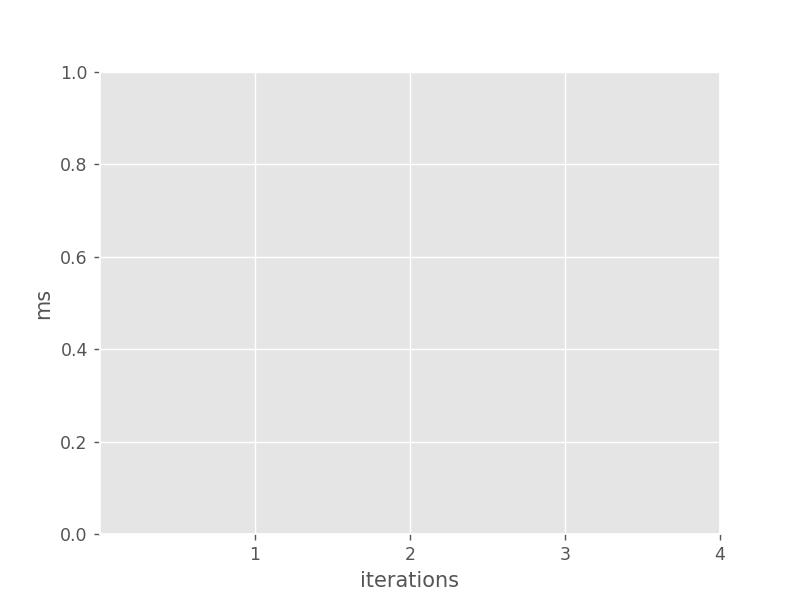

HBox()

In [102]:
%matplotlib notebook
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import *
from IPython.display import display
from IPython.html import widgets
plt.style.use("ggplot")

NUMBER_OF_PINGS = 4

# displaying the text widget
text = widgets.Text(description="Domain to ping", width=200)
display(text)

# preparing the plot 
data = pd.DataFrame()
x = range(1,NUMBER_OF_PINGS+1)
plots = dict()
fig, ax = plt.subplots()
plt.xlabel("iterations")
plt.ylabel("ms")
plt.xticks(x)
plt.show()

# preparing a container to put in created checkbox per domain
checkboxes = []
cb_container = widgets.HBox()
display(cb_container)

# add button that updates the graph based on the checkboxes
button = widgets.Button(description="Update the graph")

# function to deal with the added domain name
def handle_submit(sender):
    # a part of the magic inside python : pinging
#     res = !ping -c {NUMBER_OF_PINGS} {text.value}
    hits = 1 #res.grep("64 bytes").fields(-2).s.replace("time=","").split()
    if len(hits) == 0:
       print("Domain gave error on pinging")
    else:
         # rebuild plot based on ping result
        data = np.square(np.arange(1,11))
        data = data.astype(float)
        plots, = ax.plot(data, label=text.value)
        plt.legend()
        plt.draw()
        # add a new checkbox for the new domain
        checkboxes.append(widgets.Checkbox(description = text.value, value=True, width=90))
        cb_container.children=[i for i in checkboxes]
        if len(checkboxes) == 1:
            display(button)

# function to deal with the checkbox update button       
def on_button_clicked(b):
    for c in cb_container.children:
        if not c.value:
            plots.set_visible(False)
        else:
            plots.set_visible(True)
    plt.legend()
    plt.draw()

button.on_click(on_button_clicked)
text.on_submit(handle_submit)
plt.show()